# Lab 4 Presentation - Cross Validation

Josh Davis/Lucas Schwengber

Today’s goals (see the [exercise](lab4_exercise_2026.qmd) for the full
list):

1.  Why we need cross validation, and why it beats training error for
    choosing a model.
2.  Why training error is too optimistic, and why this gets worse as
    models get more complex.
3.  What CV error is actually an estimate of.
4.  What CV needs in order to work.
5.  How the sizes of the training and validation sets affect the bias
    and variance of the estimate.
6.  How the number of folds $K$ affects bias, variance and computation.

*This presentation is adapted from Erez Buchweitz’s cross validation
lab.*

LLM assistance was used during the elaboration of this presentation and
the exercise.

# Estimating the risk

We have training data $\mathcal{T} = (\boldsymbol{X}, \boldsymbol{y})$,
with $\boldsymbol{X}\in\mathbb{R}^{N \times P}$ and
$\boldsymbol{y}\in\mathbb{R}^N$, comprising independent and identically
distributed (IID) observations, and we fit a prediction model $\hat f$
on $\mathcal{T}$. Its **risk** is the expected loss on a new observation
$(\boldsymbol{x}, y)$ drawn from the same distribution:
$$\text{Err}_\mathcal{T} = \mathbb{E}\left[\mathscr{L}(\hat f(\boldsymbol{x}), y) \mid \mathcal{T}\right].$$
This depends on the particular training set $\mathcal{T}$ we got.
Averaging over random training sets of size $N$ gives the **expected
risk** $\text{Err} = \mathbb{E}_\mathcal{T}[\text{Err}_\mathcal{T}]$
(ESL Section 7.4).

We want to estimate the risk because:

- We want to have a sense of how good $\hat f$ is before we deploy it.
- We want to compare two candidate models $\hat f_1$ and $\hat f_2$ and
  choose the best among them.
- We want to optimize hyperparameters of $\hat f$.

## A practice world

In real life we can never compute $\text{Err}_\mathcal{T}$, so we cannot
check how good our estimates of it are. In this lab we use a simulated
binary classification problem in which we know the true probability
$p(\boldsymbol{x}) = P(y = 1 \mid \boldsymbol{x})$. For a model that
predicts probabilities $q(\boldsymbol{x})$, the log loss is
$\mathscr{L}(q(\boldsymbol{x}), y) = -y \log q(\boldsymbol{x}) - (1-y) \log(1 - q(\boldsymbol{x}))$,
and its risk is
$$\text{Err}_\mathcal{T} = \mathbb{E}_{\boldsymbol{x}}\left[-p(\boldsymbol{x}) \log q(\boldsymbol{x}) - (1 - p(\boldsymbol{x})) \log (1 - q(\boldsymbol{x}))\right],$$
where $p$ is the true probability and $q$ is the model’s prediction.

How do we compute this expectation? We draw a large sample of
$M = 20{,}000$ **new** feature vectors
$\boldsymbol{x}_1, \dots, \boldsymbol{x}_M$ from the same distribution,
which the model never saw during training, and average:
$$\text{Err}_\mathcal{T} \approx \frac{1}{M} \sum_{m=1}^M \left[-p(\boldsymbol{x}_m) \log q(\boldsymbol{x}_m) - (1 - p(\boldsymbol{x}_m)) \log (1 - q(\boldsymbol{x}_m))\right].$$
This is the log loss on a huge test set, with one change: instead of a
random label $y_m$, we use its probability $p(\boldsymbol{x}_m)$. Given
$\boldsymbol{x}$, the log loss averaged over the random label is exactly
$-p(\boldsymbol{x}) \log q(\boldsymbol{x}) - (1 - p(\boldsymbol{x})) \log(1 - q(\boldsymbol{x}))$,
so this removes the noise from the labels. `simulator.py` does this
computation in `true_risk(model)`, always with the same 20,000 feature
vectors. In real life we never know $p(\boldsymbol{x})$ and never have
unlimited new data, which is why we need the estimates in the rest of
this lab.

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import log_loss, make_scorer
from sklearn.model_selection import KFold, train_test_split, cross_val_score, cross_validate

sys.path.insert(0, "../../datasets/cv_lab")    # in your notebook: download simulator.py as in the exercise
from simulator import simulate, true_risk, bayes_risk

X, y = simulate(500, seed=7)
model = lgb.LGBMClassifier(n_jobs=1, verbosity=-1).fit(X, y)

risk, se = true_risk(model, return_se=True)
print(f"true risk of LightGBM with default settings: {risk:.3f} (standard error: {se:.4f})")
print(f"risk of always predicting 0.5:               {np.log(2):.3f}")
print(f"Bayes risk (predicting p(x) exactly):        {bayes_risk():.3f}")

true risk of LightGBM with default settings: 0.657 (standard error: 0.0028)
risk of always predicting 0.5:               0.693
Bayes risk (predicting p(x) exactly):        0.465

The standard error is tiny, so 20,000 new observations are enough to
average out the noise. In the rest of the lab, `true_risk(model)` plays
the role of the error on all future data: the quantity we are trying to
estimate, but could never compute in real life.

# Training error

The simplest estimate of the risk averages the loss over the training
set itself:
$$\widehat{\text{err}}_{\text{train}} = \frac{1}{N}\sum_{n=1}^N \mathscr{L}(\hat f(\boldsymbol{X}_{n,:}), \boldsymbol{y}_n).$$
This is a biased estimator: it is **too optimistic**. The same data is
used to fit $\hat f$ and to evaluate it, and $\hat f$ has adapted to the
noise in those particular labels. ESL (Section 7.4, eq. 7.21, p. 229)
makes this precise: on average, training error underestimates the
in-sample error by
$$\omega = \frac{2}{N}\sum_{n=1}^N \text{Cov}(\hat y_n, y_n),$$
which holds for squared error, 0-1 and log loss (for log loss,
$\hat y_n$ is the fitted probability). “The amount by which [training
error](#training-error) underestimates the true error depends on how
strongly $y_i$ affects its own prediction. The harder we fit the data,
the greater $\text{Cov}(\hat y_i, y_i)$ will be, thereby increasing the
optimism.”

An extreme example: $N = 1{,}000$ observations and $P = 1{,}000{,}000$
features that are all independent of the target, and $\hat f$ fits OLS
on the feature most correlated with the target in the training set. Out
of a million features, one is likely to be highly correlated with the
target by chance, so the training error is low; but the test predictions
are random.

Below, we make a LightGBM model more complex by adding more trees
(`n_estimators`). For each number of trees, we fit the model on our 500
training observations and compute two numbers:

- the **training error**: the log loss on the same 500 observations the
  model was fit on,
- the **true risk**: `true_risk(model)`, computed on 20,000 new
  observations as above.

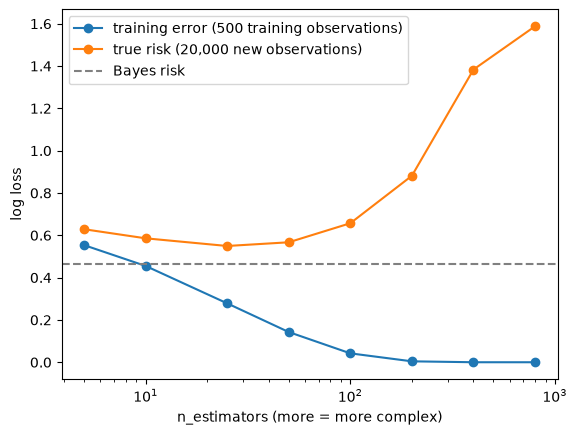

In [3]:
n_trees = [5, 10, 25, 50, 100, 200, 400, 800]
train_err, risk = [], []
for n in n_trees:
    model = lgb.LGBMClassifier(n_estimators=n, n_jobs=1, verbosity=-1).fit(X, y)
    train_err.append(log_loss(y, model.predict_proba(X)[:, 1]))
    risk.append(true_risk(model))

plt.plot(n_trees, train_err, "o-", label="training error (500 training observations)")
plt.plot(n_trees, risk, "o-", label="true risk (20,000 new observations)")
plt.axhline(bayes_risk(), color="gray", ls="--", label="Bayes risk")
plt.xscale("log"); plt.xlabel("n_estimators (more = more complex)"); plt.ylabel("log loss")
plt.legend(); plt.show()

Training error keeps going down to 0, while the true risk is minimized
at a moderate number of trees and then gets much worse. Choosing the
number of trees by minimizing training error would pick the most overfit
model. We need an estimate that uses data the model has not seen.

# Validation error

We split the training data into two non-overlapping sets
$(\boldsymbol{X}_{\text{train}},\boldsymbol{y}_{\text{train}})$ and
$(\boldsymbol{X}_{\text{valid}}, \boldsymbol{y}_{\text{valid}})$
comprising $N_{\text{train}}$ and $N_{\text{valid}}$ observations,
respectively. We fit $\hat f$ on
$(\boldsymbol{X}_{\text{train}}, \boldsymbol{y}_{\text{train}})$ and
estimate the risk by averaging the loss over the validation set:
$$\widehat{\text{err}}_{\text{valid}} = \frac{1}{N_{\text{valid}}}\sum_{n=1}^{N_{\text{valid}}} \mathscr{L}\left(\hat f((\boldsymbol{X}_{\text{valid}})_{n,:}), (\boldsymbol{y}_{\text{valid}})_{n}\right).$$

Because the validation observations are new to $\hat f$, this is an
unbiased estimator of the risk of $\hat f$, **the model trained on
$N_{\text{train}}$ observations**. But we eventually train our final
model on all $N$ ($> N_{\text{train}}$) observations, and a model
trained on more data usually has lower risk. So as an estimate of the
risk of the final model, validation error is biased: typically **too
pessimistic**.

If $N_{\text{train}}$ is increased (and so $N_{\text{valid}}$ is
decreased):

- The bias decreases, because the model we evaluate is closer to the
  final model.
- The variance increases, because we average over fewer validation
  observations.

A single split cannot make both small. For IID data it makes no
difference *which* observations go to validation, as long as the split
is random (see the last section).

In [4]:
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=0)
model = lgb.LGBMClassifier(n_jobs=1, verbosity=-1).fit(X_tr, y_tr)
print(f"N_train = {len(y_tr)}, N_valid = {len(y_va)}")
print(f"validation error:                 {log_loss(y_va, model.predict_proba(X_va)[:, 1]):.3f}")
print(f"true risk of this model:          {true_risk(model):.3f}")

N_train = 400, N_valid = 100
validation error:                 0.679
true risk of this model:          0.644

On a single dataset the two numbers differ, because validation error is
a noisy estimate. Note however, that unlike single split train/val
estimation, CV also provide us with a means of estimating the
uncertainty in our estimate, which here is consistent with how the
actual shift relative to the true risk.

In the exercise you will repeat computations like this over many
simulated datasets to see the bias and the variance, and compare with
the risk of the model trained on all $N$ points.

# Cross validation

We split the training data into $K$ non-overlapping, equal-sized folds
$(\boldsymbol{X}^1,\boldsymbol{y}^1), \dots,(\boldsymbol{X}^K, \boldsymbol{y}^K)$,
chosen at random. For each $k=1,\dots,K$:

- Fit $\hat f^{(-k)}$ on all folds except the $k$’th.
- Compute the loss on the $k$’th fold:
  $$\widehat{\text{err}}_k = \frac{K}{N}\sum_{n=1}^{N/K} \mathscr{L}\left(\hat f^{(-k)}((\boldsymbol{X}^k)_{n,:}), (\boldsymbol{y}^k)_{n}\right).$$

The CV estimate averages over the folds:
$$\widehat{\text{err}}_{\text{CV}} = \frac{1}{K} \sum_{k=1}^K \widehat{\text{err}}_k.$$
Every observation is used for validation exactly once, so we average
over all $N$ observations instead of $N_{\text{valid}}$ of them.

In scikit-learn, `KFold` produces the indices of the folds, and
`cross_val_score` runs the whole procedure: it fits a fresh copy of the
model on each training fold and scores it on the validation fold. Note
`shuffle=True`: by default, `KFold` does **not** shuffle, and the folds
are consecutive blocks of rows.

In [6]:
cv = KFold(5, shuffle=True, random_state=0)
for k, (train_idx, val_idx) in enumerate(cv.split(X)):
    print(f"fold {k}: train on {len(train_idx)} rows, validate on {len(val_idx)} rows, first validation rows {val_idx[:5]}")

# scikit-learn maximizes scores, so the scorer returns the *negative* log loss.
# labels=[0, 1] keeps it working when a validation fold contains only one class.
log_loss_scorer = make_scorer(log_loss, greater_is_better=False, response_method="predict_proba", labels=[0, 1])
res = cross_validate(lgb.LGBMClassifier(n_jobs=1, verbosity=-1), X, y, cv=cv,
                     scoring=log_loss_scorer, return_estimator=True)
fold_err = -res["test_score"]
print("validation log loss of each fold:", np.round(fold_err, 3))
print(f"5-fold CV error: {fold_err.mean():.3f}  (sd across folds: {fold_err.std(ddof=1):.3f}, "
      f"standard error of avg.: {fold_err.std(ddof=1) / np.sqrt(len(fold_err)):.3f})")

# ground truth, available only in the simulation
risk_full = true_risk(lgb.LGBMClassifier(n_jobs=1, verbosity=-1).fit(X, y))
risk_folds = np.mean([true_risk(m) for m in res["estimator"]])
print(f"true risk of the model trained on all N = {len(y)} points:          {risk_full:.3f}")
print(f"average true risk of the fold models (N_train = {len(y) * 4 // 5}):  {risk_folds:.3f}")

fold 0: train on 400 rows, validate on 100 rows, first validation rows [ 1 10 12 15 21]
fold 1: train on 400 rows, validate on 100 rows, first validation rows [4 5 6 7 8]
fold 2: train on 400 rows, validate on 100 rows, first validation rows [ 2 17 24 27 29]
fold 3: train on 400 rows, validate on 100 rows, first validation rows [ 0  3 11 13 16]
fold 4: train on 400 rows, validate on 100 rows, first validation rows [ 9 25 28 31 32]
validation log loss of each fold: [0.679 0.495 0.683 0.734 0.494]
5-fold CV error: 0.617  (sd across folds: 0.114, standard error of avg.: 0.051)
true risk of the model trained on all N = 500 points:          0.657
average true risk of the fold models (N_train = 400):  0.651

## What does CV error estimate?

Each $\hat f^{(-k)}$ is trained on $N - N/K$ observations and evaluated
on observations it has not seen. So, if implemented correctly and with
no distribution shift, **CV error is unbiased for the expected risk of a
model trained on $N - N/K$ points.** As with validation error, because
the final model is trained on all $N$ points, CV error slightly
overestimates its risk.

Note that this is the *expected* risk $\text{Err}$, averaged over
training sets, not $\text{Err}_\mathcal{T}$, the risk of the model
trained on our particular dataset $\mathcal{T}$. ESL (Section 7.10.1,
p. 242): “It turns out that cross-validation only estimates effectively
the average error Err.” In ESL’s simulation (Section 7.12, p. 254), CV
curves track the expected error well, but CV estimates show little
correlation with each training set’s own conditional error, even for
leave-one-out CV.

**What does CV hyperparameter tuning optimize?** Ideally, we want the
hyperparameter $\alpha$ that minimizes the risk of the model trained on
our dataset, $\text{Err}_\mathcal{T}(\alpha)$. CV cannot estimate this
directly, because estimating the risk of a model trained on
$\mathcal{T}$ requires data independent of $\mathcal{T}$. Averaging over
models fit on different subsets, CV tracks the expected risk
$\text{Err}(\alpha)$. So CV picks the $\alpha$ that is best for a
typical dataset like ours, which is usually also a good choice for ours.

## How many folds?

If $K$ is increased:

- The bias decreases, because each $\hat f^{(-k)}$ is trained on
  $N - N/K$ points, closer to $N$.
- The computational burden increases, because we fit $K$ models.
- The effect on variance is **not monotone**. We have two competing
  forces: we are averaging more terms, which typically reduces variance,
  but these terms are becoming increasingly more correlated since the
  training sets overlap more, which increases variance. Which effect
  dominates and when tends to be problem dependent.

As an example of the second effect, ESL (Section 7.10.1, p. 242): with
$K = N$ (leave-one-out), “the cross-validation estimator is
approximately unbiased for the true (expected) prediction error, but can
have high variance because the N ‘training sets’ are so similar to one
another.” In ESL’s simulation (Section 7.12), 10-fold CV had lower
variance than leave-one-out.

This is why $K = 5$ or $K = 10$ is common: most of the bias is gone, the
computation is moderate, and there is little to gain in variance from
larger $K$.

# What CV needs in order to work

CV error estimates the risk on future data only if:

1.  **The validation data must not be used in training**, in any way.
    This includes anything that looks at the validation labels:
    selecting features, choosing transformations, or the same
    observation appearing in both training and validation.
2.  **The validation data must be distributed like the data the model
    will be used on.** For IID data, a random train-validation split
    achieves this. A non-random split, for example consecutive rows of a
    file that is sorted, does not.

## Example: using the validation data without noticing

Here is the example from ESL Section 7.10.2. We have $N = 100$
observations, $P = 2{,}000$ features, and labels that are **independent
of all features**, so every classifier has a 50% error rate. Suppose we:

1.  select the 20 features most associated with the labels, using
    scikit-learn’s `SelectKBest` (for two classes, its default F
    statistic ranks features the same way as their correlation with the
    label), then
2.  use 5-fold CV to estimate the misclassification error of a model on
    those 20 features.

The wrong way is to do step 1 once, on all the data. The right way is to
repeat step 1 inside each fold, using only the training folds.

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import make_pipeline

wrong, right = [], []
for r in range(10):
    rng = np.random.default_rng(r)
    X_noise = rng.normal(size=(100, 2000))
    y_noise = rng.binomial(1, 0.5, size=100)
    model = lgb.LGBMClassifier(min_child_samples=10, n_jobs=1, verbosity=-1)
    cv = KFold(5, shuffle=True, random_state=r)

    # wrong: select features once, using all the labels (including the validation folds')
    X_selected = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)
    wrong.append(1 - cross_val_score(model, X_selected, y_noise, cv=cv, scoring="accuracy").mean())

    # right: the pipeline repeats the selection inside each fold, using the training folds only
    pipeline = make_pipeline(SelectKBest(f_classif, k=20), model)
    right.append(1 - cross_val_score(pipeline, X_noise, y_noise, cv=cv, scoring="accuracy").mean())

print(f"CV misclassification error, selecting on all data:     {np.mean(wrong):.0%}")
print(f"CV misclassification error, selecting inside each fold: {np.mean(right):.0%}")
print("true misclassification error: 50%")

CV misclassification error, selecting on all data:     23%
CV misclassification error, selecting inside each fold: 49%
true misclassification error: 50%

Selecting on all the data chose features that are correlated with the
validation labels by chance, so CV reports a much lower error than any
classifier can achieve. In the exercise you will break each of the two
principles in other ways, and see how to fix them. In scikit-learn, the
safe habit is to put every step that learns from the data (feature
selection, scaling, imputation) into a `Pipeline` together with the
model, and cross-validate the whole pipeline.

# Summary

| Estimate | Unbiased for | As an estimate of the final model’s risk | Variance |
|------------------|------------------|------------------|------------------|
| Training error | not the risk (it measures the fit to the training labels) | too optimistic, worse for complex models |  |
| Validation error | risk of the model trained on $N_{\text{train}}$ points | too pessimistic; less so as $N_{\text{train}} \to N$ | grows as $N_{\text{valid}}$ shrinks |
| $K$-fold CV error | expected risk of a model trained on $N - N/K$ points | slightly pessimistic; less so as $K$ grows | not monotone in $K$ |

In the exercise you will see each row of this table in the practice
world, where you can compare every estimate with the true risk. Then you
will use CV to tune LightGBM on a challenge dataset with no true risk,
as in real life.